<a href="https://colab.research.google.com/github/alemcastro/cambridge_projects/blob/main/CAM_DS_301_W8_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br>

**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Activity 8.2.3 Performing time series forecasting with machine learning and deep learning

## Scenario
The Baltimore Police Department (BPD), situated in Baltimore, USA, created a data set containing crime records from 1 January 2011 to 18 June 2016. Although the data set is preliminary and subject to change, it contains 264,496 rows and 11 columns (BPD, 2024).

For this activity, the data set was adapted to indicate the number of daily crime incidents from 1 January 2011 to 31 December 2015. Therefore, the data set contains 2,143 rows and two columns. You are tasked to analyse the provided data set to determine visible crime trends. You must also provide a clear and precise rationale for your analysis and findings.


## Objective
In this portfolio activity, you will analyse a time series data set to gain insights into crime trends.

You will complete the activity in your Notebook, where you will:

* Load the preprocessed time series data set.
* Split the data set into training and testing sets.
* Choose a suitable machine learning technique (e.g. LightGBM, XGBoost) and train a model on the training data.
* Implement a deep learning model (e.g. LSTM) for time series forecasting and train it on the same data set.
* Compare the performance of the deep learning model with the machine learning model.
* Explore hybrid techniques by combining the results of classical and machine learning models.
* Present the findings, model comparisons, and insights from the forecasting analysis.



## Assessment criteria
By completing this activity, you will be able to provide evidence that you can critically select appropriate strategies to demonstrate expertise in building and refining decision trees and ensemble techniques.


## Activity guidance

* Load the preprocessed time series data set.
* Split the data set into training and testing sets.
* Choose a suitable machine learning technique (e.g., LightGBM, XGBoost) and train a model on the training data.
* Implement a deep learning model (e.g., LSTM) for time series forecasting and train it on the same data set.
* Compare the performance of the deep learning model with the machine learning model.
* Explore hybrid techniques by combining the results of classical and machine learning models.
* Present the findings, model comparisons, and insights from the forecasting analysis.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/crime_incidents.csv'

In [ ]:
crime = pd.read_csv(url)
crime.head()

,date,incidents
0,01-01-11,185.0
1,01-01-12,176.0
2,01-01-13,157.0
3,01-01-14,139.0
4,01-01-15,157.0


In [ ]:
# Load the preprocessed time series data set. Preprocess convert dates, sort, set daily frequency, impute (spline) — same as before.
crime['date'] = pd.to_datetime(crime['date'], format='mixed')
crime.set_index('date', inplace=True)
crime.sort_index(inplace=True)
crime = crime.asfreq('d')
crime['incidents_imputed_spline'] = crime['incidents'].interpolate(method='spline', order=3)

print('Rows:', len(crime), '| missing after impute:', crime['incidents_imputed_spline'].isna().sum())
crime.head()

Rows: 2143 | missing after impute: 0


,incidents,incidents_imputed_spline
date,,
2011-01-01,185.0,185.0
2011-01-02,102.0,102.0
2011-01-03,106.0,106.0
2011-01-04,113.0,113.0
2011-01-05,131.0,131.0


Data is going to be process daily to get enought data to be process by the models.

In [ ]:
# Split the data set into training and testing sets.
series = crime['incidents_imputed_spline']

test_size = 365
train = series[:-test_size]
test = series[-test_size:]

print('Train points:', len(train))
print('Test points:', len(test))
print('Train range:', train.index.min().date(), '->', train.index.max().date())
print('Test range: ', test.index.min().date(), '->', test.index.max().date())

Train points: 1778
Test points: 365
Train range: 2011-01-01 -> 2015-11-13
Test range:  2015-11-14 -> 2016-11-12


In [ ]:
# Choose a suitable machine learning technique (XGBoost) and train a model on the training data.
df_feat = crime[['incidents_imputed_spline']].copy()
df_feat.columns = ['y']

# Lag features: value N days ago
df_feat['lag_1']   = df_feat['y'].shift(1)
df_feat['lag_7']   = df_feat['y'].shift(7)
df_feat['lag_365'] = df_feat['y'].shift(365)

# Calendar features
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month']     = df_feat.index.month

# Drop rows with NaN lags (the first 365 rows lack a lag_365 value)
df_feat = df_feat.dropna()

print('Rows after feature engineering:', len(df_feat))
print('Columns:', df_feat.columns.tolist())
df_feat.head()

Rows after feature engineering: 1778
Columns: ['y', 'lag_1', 'lag_7', 'lag_365', 'dayofweek', 'month']


,y,lag_1,lag_7,lag_365,dayofweek,month
date,,,,,,
2012-01-01,176.0,112.0,92.0,185.0,6,1
2012-01-02,105.0,176.0,114.0,102.0,0,1
2012-01-03,99.0,105.0,102.0,106.0,1,1
2012-01-04,121.0,99.0,109.0,113.0,2,1
2012-01-05,131.0,121.0,133.0,131.0,3,1


In [ ]:
# Split features chronologically (same 365-day holdout), then train XGBoost.
feature_cols = ['lag_1', 'lag_7', 'lag_365', 'dayofweek', 'month']

X = df_feat[feature_cols]
y = df_feat['y']

# Chronological split — last 365 rows as test (NO shuffle)
X_train, X_test = X[:-365], X[-365:]
y_train, y_test = y[:-365], y[-365:]

print('Train:', X_train.shape, '| Test:', X_test.shape)

# Train the XGBoost regressor
model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
model_xgb.fit(X_train, y_train)

# Predict on the test set
pred_xgb = model_xgb.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse_xgb = mean_squared_error(y_test, pred_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f'XGBoost — MSE: {mse_xgb:.2f} | MAE: {mae_xgb:.2f} | RMSE: {mse_xgb**0.5:.2f}')

Train: (1413, 5) | Test: (365, 5)
XGBoost — MSE: 360.77 | MAE: 14.57 | RMSE: 18.99


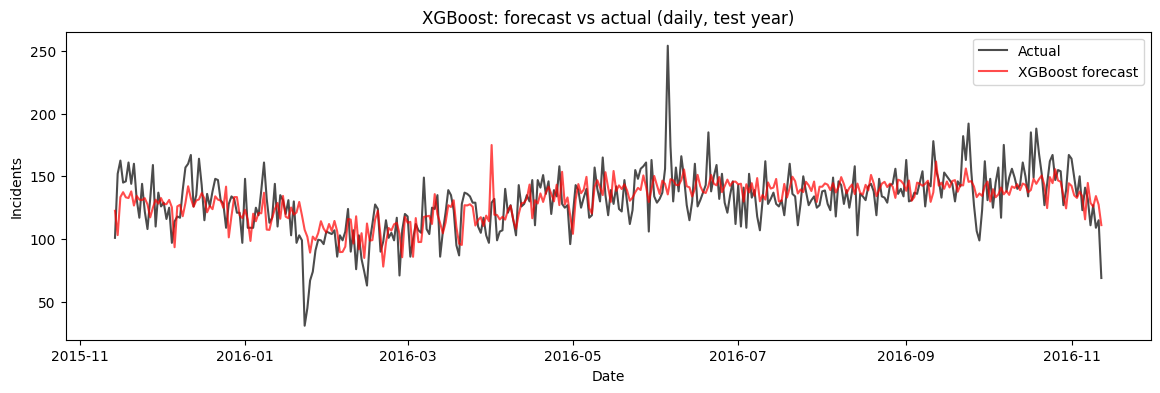

In [ ]:
# Visualise XGBoost forecast vs actual test values.
plt.figure(figsize=(14, 4))
plt.plot(y_test.index, y_test, label='Actual', color='black', alpha=0.7)
plt.plot(y_test.index, pred_xgb, label='XGBoost forecast', color='red', alpha=0.7)
plt.title('XGBoost: forecast vs actual (daily, test year)')
plt.xlabel('Date'); plt.ylabel('Incidents')
plt.legend(); plt.show()

The red line is smoother than the black. It misses the sharp spikes and deep dips. The model captures the signal (the pattern) but not the noise (the day-to-day volatility and one-off extremes). It is likely the model is overfitting.

In [ ]:
# Quick hyperparameter tuning for XGBoost using time-series CV.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 6],
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)

# Evaluate the tuned model on the test set
best_xgb = grid.best_estimator_
pred_xgb_tuned = best_xgb.predict(X_test)
mse_t = mean_squared_error(y_test, pred_xgb_tuned)
mae_t = mean_absolute_error(y_test, pred_xgb_tuned)
print(f'Tuned XGBoost — MSE: {mse_t:.2f} | MAE: {mae_t:.2f} | RMSE: {mse_t**0.5:.2f}')
print(f'(Untuned was — MSE: {mse_xgb:.2f} | RMSE: {mse_xgb**0.5:.2f})')

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Tuned XGBoost — MSE: 339.94 | MAE: 14.03 | RMSE: 18.44
(Untuned was — MSE: 360.77 | RMSE: 18.99)


Improvements are small compared to the previous model.

In [ ]:
# Implement a deep learning model (LSTM) and train it.
from sklearn.preprocessing import MinMaxScaler

# Use the same daily series and the SAME chronological split point (last 365 days = test)
values = crime['incidents_imputed_spline'].values.reshape(-1, 1)

split_idx = len(values) - 365
train_vals = values[:split_idx]
test_vals  = values[split_idx:]

# Scale using ONLY the training data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_vals)
test_scaled  = scaler.transform(test_vals)

# Build sequences: use the last `look_back` days to predict the next day
look_back = 30

def make_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = make_sequences(train_scaled, look_back)
X_test_lstm,  y_test_lstm  = make_sequences(test_scaled, look_back)

# LSTM expects shape
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], look_back, 1))
X_test_lstm  = X_test_lstm.reshape((X_test_lstm.shape[0], look_back, 1))

print('X_train_lstm:', X_train_lstm.shape, '| X_test_lstm:', X_test_lstm.shape)

X_train_lstm: (1748, 30, 1) | X_test_lstm: (335, 30, 1)


In [ ]:
# Define and train the LSTM.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

tf.random.set_seed(42)

model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(look_back, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0116 - val_loss: 0.0017
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_l

The loss dropped fast in the first ~5 epochs (0.0116 - 0.0027) and then flatlined: from epoch ~5 onward, both loss (0.0026) and val_loss (0.0017) barely move. So the model learned what it could quickly and then plateaued.

In [ ]:
# Predict on test, invert scaling, evaluate in real incident units.
pred_lstm_scaled = model_lstm.predict(X_test_lstm)

# Invert the 0-1 scaling back to real incident counts
pred_lstm = scaler.inverse_transform(pred_lstm_scaled).flatten()
y_test_lstm_real = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

# Evaluate on the same footing as XGBoost (real incidents)
mse_lstm = mean_squared_error(y_test_lstm_real, pred_lstm)
mae_lstm = mean_absolute_error(y_test_lstm_real, pred_lstm)
print(f'LSTM — MSE: {mse_lstm:.2f} | MAE: {mae_lstm:.2f} | RMSE: {mse_lstm**0.5:.2f}')
print(f'Tuned XGBoost — MSE: {mse_t:.2f} | MAE: {mae_t:.2f} | RMSE: {mse_t**0.5:.2f}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
LSTM — MSE: 354.50 | MAE: 13.79 | RMSE: 18.83
Tuned XGBoost — MSE: 339.94 | MAE: 14.03 | RMSE: 18.44


Both models were scored on slightly different test set sizes (365 vs 335) as a side effect of how the LSTM builds its input sequences. Given this — and the points below — neither model can be declared a clear winner.

- The LSTM did not outperform the tuned XGBoost — both landed at RMSE ≈ 18 - 19 (XGBoost 18.44, LSTM 18.83), a difference too small to be practically meaningful.
- The metrics split slightly: XGBoost edged MSE/RMSE (better at controlling large misses), while the LSTM edged MAE (smaller typical error) — a real, explainable behavioural difference.
- Three approaches converged on the same ~18 RMSE (XGBoost, tuning, and a different architecture in the LSTM), suggesting this is close to the daily series' irreducible noise floor rather than a limit of any one model.

In summary:
- The gap is tiny, 18.44 vs 18.83 is well within noise.
- The test sets differ (365 vs 335), then it's not a clean head-to-head.
- LSTM results vary run-to-run, re-run it and the ordering could flip.

In [ ]:
# Explore hybrid techniques by combining models.
# Combine XGBoost and LSTM models to the SAME test days
pred_xgb_aligned = pred_xgb_tuned[-335:]
y_actual_aligned = y_test.values[-335:]

# Sanity check: everything must be the same length and refer to the same days
print('Lengths — XGB:', len(pred_xgb_aligned),
      '| LSTM:', len(pred_lstm),
      '| actual:', len(y_actual_aligned))

# --- Hybrid: simple 50/50 average ---
pred_hybrid = (pred_xgb_aligned + pred_lstm) / 2

# --- Evaluate all three on the SAME 335 days ---
def scores(name, actual, pred):
    mse = mean_squared_error(actual, pred)
    mae = mean_absolute_error(actual, pred)
    print(f'{name:16s} MSE: {mse:7.2f} | MAE: {mae:6.2f} | RMSE: {mse**0.5:.2f}')

print()
scores('XGBoost',  y_actual_aligned, pred_xgb_aligned)
scores('LSTM',     y_actual_aligned, pred_lstm)
scores('Hybrid',   y_actual_aligned, pred_hybrid)

Lengths — XGB: 335 | LSTM: 335 | actual: 335

XGBoost          MSE:  333.41 | MAE:  13.73 | RMSE: 18.26
LSTM             MSE:  354.50 | MAE:  13.79 | RMSE: 18.83
Hybrid           MSE:  328.47 | MAE:  13.28 | RMSE: 18.12


The results show the hibrid approach wins on the thre metrics. The test size was ajusted to 335 to be get the same size for boths models. Event though they produced small changes, they were consistent improvement over both individual models (RMSE 18.12 vs 18.26 and 18.83), indicating the two models make partially independent errors that averaging helps cancel.

### Reflect

For Baltimore PD, these models reliably track the overall level and seasonal movement of daily crime incidents, with a typical error of roughly 13 - 14 incidents per day. That makes them useful for anticipating general demand and planning resourcing at a strategic level. Critically, though, none could predict individual extreme days — the sharp one-off spikes in the data went uncaptured by every model. The forecasts are therefore best used for planning-level decisions (seasonal staffing, budget allocation, holiday staff planning) rather than day-specific deployment. And since the deep learning model offered no accuracy gain over the far simpler and more interpretable tree model, XGBoost — or the marginally better hybrid — is the more practical operational choice, balancing accuracy against cost and explainability.

Results (uneven test sets — XGBoost on 365 days, LSTM on 335):
- XGBoost (tuned): RMSE 18.44 | MSE 339.94 | MAE 14.03 — lower MSE/RMSE.
- LSTM: RMSE 18.83 | MSE 354.50 | MAE 13.79 — lower MAE.


Results (same 335-day test set):
- XGBoost (tuned): RMSE 18.26 (best individual model), suggesting it was already near the data's predictive limit.
- LSTM: RMSE 18.83.
- Hybrid (50/50 average): RMSE 18.12 and our best overall, beating both individual models, as partially independent errors cancel out.

Overall: all three converged on RMSE ≈ 18-19, pointing to an irreducible noise floor in the daily series rather than a weakness in any one model.

The small gains available suggest limited value in chasing accuracy through more complex models; a more productive direction would be richer features (e.g. weather, public holidays, local events) that might explain some of the spikes currently treated as noise. The model comparison could also be made fully rigorous by aligning the LSTM to the complete 365-day test set, and the LSTM's run-to-run variability addressed by averaging several runs. For deployment, the recommended approach is to use the model for strategic planning, monitor its accuracy as new data arrives, and re-train periodically.